In [1]:
import os
import cv2 as cv
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import re

from pathlib import Path
from collections import Counter
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
print("Tensorflow version: ", tf.__version__)

seed = 1234
np.random.seed(seed)
tf.random.set_seed(seed)

Tensorflow version:  2.16.1


In [2]:
train_dir = Path('/kaggle/input/captcha-dataset/train')
test_dir = Path('/kaggle/input/captcha-dataset/test')
base_dir = Path('/kaggle/input/captcha-dataset')

In [3]:
train_images_paths = list(train_dir.glob('*.png'))
print("number of images: ", len(train_images_paths))

number of images:  8000


In [4]:
test_images_paths = list(test_dir.glob('*.png'))
print("number of images: ", len(test_images_paths))

number of images:  2000


Shape of image:  (80, 240, 3)
Shape of image:  (80, 405, 3)
Shape of image:  (80, 275, 3)
Shape of image:  (80, 530, 3)


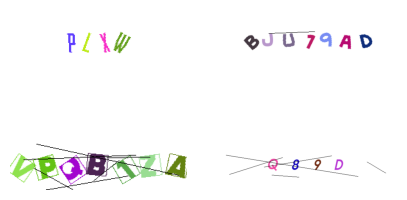

In [5]:
sample_image_paths = train_images_paths[:4]
_,ax = plt.subplots(2,2, figsize=(5,3))
for i in range(4):
    img = cv.imread(str(sample_image_paths[i]))
    print("Shape of image: ", img.shape)
    ax[i//2, i%2].imshow(img)
    ax[i//2, i%2].axis('off')
plt.show()

In [6]:
# Dilation
def dilation(image):
    kernel = np.ones((2, 2), np.uint8)
    dilated_image = cv.dilate(image, kernel)
    return dilated_image

# Erosion
def erosion_line(image):
    kernel = np.ones((2, 2), np.uint8)
    eroded_image = cv.erode(image, kernel)
    return eroded_image

# Noise Line Extraction
def get_noiseline(image, first, k1size, k2size):
    kernel1 = np.ones((k1size, k1size), np.uint8)
    kernel2 = np.ones((k2size, k2size), np.uint8)
    if first == "dilation":
        temp = cv.dilate(image, kernel1)
        noiseline = cv.erode(temp, kernel2)
    else:
        temp = cv.erode(image, kernel1)
        noiseline = cv.dilate(temp, kernel2)
    return noiseline

# Noise Line Removal
def remove_noiseline(image, noiseline):
    result = image.copy()
    mask = noiseline == 0
    result[mask] = 255
    return result

# Bilateral Filtering
def bilateral_filtering(image, d=9, sigmaColor=75, sigmaSpace=75):
    filtered_image = cv.bilateralFilter(image, d, sigmaColor, sigmaSpace)
    return filtered_image

# finding valleys in image
def find_valleys(projection, min_valley_depth=0.5, min_peak_distance=5):
    """
    Find significant valleys in the projection profile that could indicate character separation.

    Args:
        projection: 1D numpy array of the vertical projection
        min_valley_depth: Minimum depth ratio relative to surrounding peaks to be considered a valley
        min_peak_distance: Minimum distance between valleys

    Returns:
        List of valley positions (x-coordinates)
    """
    # Smooth the projection to reduce noise
    smoothed = np.convolve(projection, np.ones(3)/3, mode='same')

    valleys = []
    for i in range(1, len(smoothed)-1):
        # Check if this point is a local minimum
        if smoothed[i-1] > smoothed[i] < smoothed[i+1]:
            # Find the nearest peaks on both sides
            left_peak = max(smoothed[max(0, i-min_peak_distance):i])
            right_peak = max(smoothed[i+1:min(len(smoothed), i+min_peak_distance)])

            # Calculate valley depth relative to smaller peak
            min_peak_height = min(left_peak, right_peak)
            valley_depth = (min_peak_height - smoothed[i]) / min_peak_height

            # If valley is deep enough, add it to the list
            if valley_depth > min_valley_depth:
                valleys.append(i)

    return valleys

def should_split_contour(x, y, w, h, binary_image):
    """More sophisticated splitting decision"""
    # Extract the region
    region = binary_image[y:y+h, x:x+w]

    # Analyze vertical histogram
    vertical_projection = np.sum(region, axis=0)

    # Find valleys in the projection
    valleys = find_valleys(vertical_projection)

    # Check if there's a significant valley
    return len(valleys) > 0 and min(valleys) < 0.3 * max(vertical_projection)

def merge_narrow_segments(split_points, min_width):
    """
    Merge segments that are too narrow with their neighbors.
    """
    if not split_points:
        return split_points

    result = []
    current_start, current_width = split_points[0]

    for i in range(1, len(split_points)):
        next_start, next_width = split_points[i]

        if current_width < min_width:
            # Merge with the next segment
            current_width = (next_start + next_width) - current_start
        else:
            result.append((current_start, current_width))
            current_start, current_width = next_start, next_width

    # Add the last segment
    result.append((current_start, current_width))
    return result

def merge_same_letter_bounding_boxes(boxes):
    """
    Merge boxes that belong to the same letter, specifically for letters like 'i' and 'j'
    where one box represents the main body and a smaller box represents the dot.
    
    Args:
        boxes (list of tuple): List of bounding boxes, where each box is represented as (x, y, width, height).
        
    Returns:
        List of merged bounding boxes, each represented as (x, y, width, height).
    """
    
    # Sort boxes by x coordinate for left-to-right processing
    boxes = sorted(boxes, key=lambda box: box[0])
    merged_boxes = []
    skip_indices = set()

    def should_merge(box1, box2):
        # Unpack box dimensions
        x1, y1, w1, h1 = box1
        x2, y2, w2, h2 = box2

        # Determine the larger and smaller box
        if w1 * h1 > w2 * h2:
            larger, smaller = box1, box2
        else:
            larger, smaller = box2, box1

        # Calculate proximity thresholds
        vertical_proximity_threshold = max(h1, h2) * 1.5  # Allow vertical gap for dots above stems
        horizontal_proximity_threshold = max(w1, w2) * 0.6  # Allow some horizontal offset

        # Check if smaller box is vertically close above the larger box
        vertically_close = abs((smaller[1] + smaller[3]) - larger[1]) < vertical_proximity_threshold
        horizontally_close = abs((smaller[0] + smaller[2] / 2) - (larger[0] + larger[2] / 2)) < horizontal_proximity_threshold

        # Ensure merging would not distort aspect ratio
        merged_x = min(x1, x2)
        merged_y = min(y1, y2)
        merged_width = max(x1 + w1, x2 + w2) - merged_x
        merged_height = max(y1 + h1, y2 + h2) - merged_y
        merged_aspect_ratio = merged_width / merged_height
        
        # Aspect ratio condition to avoid wide or tall merged boxes
        original_aspect_ratio = larger[2] / larger[3]
        aspect_ratio_condition = abs(merged_aspect_ratio - original_aspect_ratio) < 0.5 * original_aspect_ratio

        return vertically_close and horizontally_close and aspect_ratio_condition

    def merge_boxes(box1, box2):
        # Merges two boxes into a single bounding box that covers both
        x1, y1, w1, h1 = box1
        x2, y2, w2, h2 = box2

        merged_x = min(x1, x2)
        merged_y = min(y1, y2)
        merged_width = max(x1 + w1, x2 + w2) - merged_x
        merged_height = max(y1 + h1, y2 + h2) - merged_y

        return (merged_x, merged_y, merged_width, merged_height)

    for i, box in enumerate(boxes):
        if i in skip_indices:
            continue
        
        merged_box = box  # Start with the current box as the merged candidate

        for j in range(i + 1, len(boxes)):
            if j in skip_indices:
                continue
            
            # Check if the current box should merge with the next one
            if should_merge(merged_box, boxes[j]):
                merged_box = merge_boxes(merged_box, boxes[j])
                skip_indices.add(j)  # Mark this box as merged

        merged_boxes.append(merged_box)

    return merged_boxes

def split_contour_once(x, y, w, h):
    """
    Split the bounding box vertically in the middle.
    """
    # Split vertically in the middle
    split_point = w // 2

    # Left bounding box
    x_left = x
    w_left = split_point

    # Right bounding box
    x_right = x + split_point
    w_right = w - split_point

    # Return the two bounding boxes
    return [(x_left, y, w_left, h), (x_right, y, w_right, h)]

def non_max_suppression_fast(boxes, overlap_thresh=0.3):
    """
    Perform Non-Maximum Suppression on the bounding boxes.
    """
    if len(boxes) == 0:
        return []

    # Convert to float if necessary
    if boxes.dtype.kind == "i":
        boxes = boxes.astype("float")

    pick = []

    x1 = boxes[:,0]
    y1 = boxes[:,1]
    x2 = boxes[:,0] + boxes[:,2]
    y2 = boxes[:,1] + boxes[:,3]

    area = (x2 - x1) * (y2 - y1)
    idxs = np.argsort(y2)

    while len(idxs) > 0:
        last = len(idxs) - 1
        i = idxs[last]
        pick.append(i)

        xx1 = np.maximum(x1[i], x1[idxs[:last]])
        yy1 = np.maximum(y1[i], y1[idxs[:last]])
        xx2 = np.minimum(x2[i], x2[idxs[:last]])
        yy2 = np.minimum(y2[i], y2[idxs[:last]])

        w = np.maximum(0, xx2 - xx1)
        h = np.maximum(0, yy2 - yy1)

        overlap = (w * h) / area[idxs[:last]]

        idxs = np.delete(idxs, np.concatenate(([last], np.where(overlap > overlap_thresh)[0])))

    return boxes[pick].astype("int")

def show_image(title, img):
    """
    Utility function to display an image using matplotlib.
    """
    if img is None or img.dtype != np.uint8:
        print(f"Error displaying image: {title}. Image data is None or not valid.")
        return
    plt.figure(figsize=(6, 6))
    plt.imshow(img, cmap='gray')
    plt.title(title)
    plt.axis('off')
    plt.show()

# Actual Pipeline

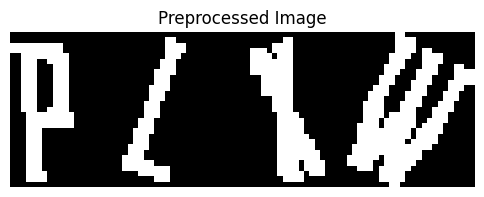

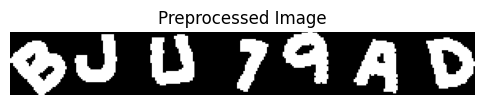

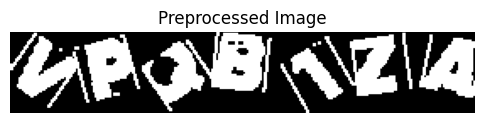

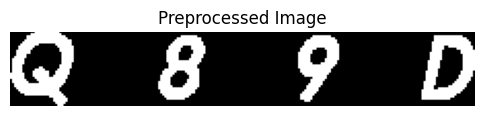

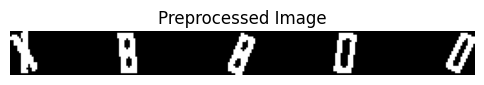

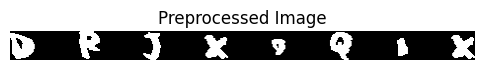

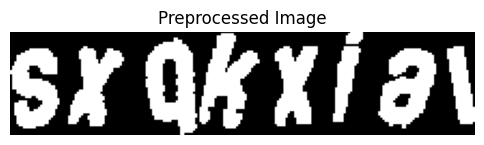

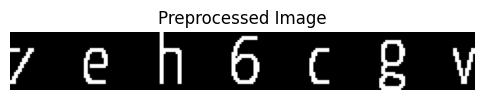

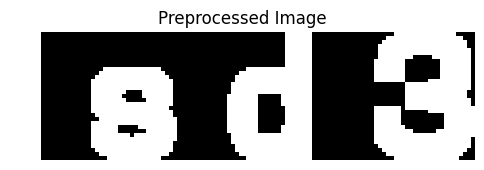

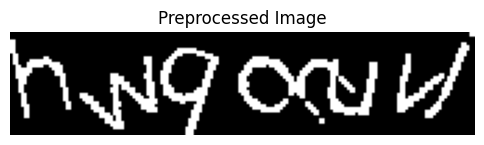

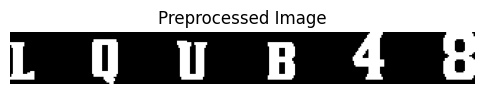

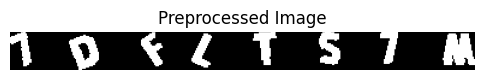

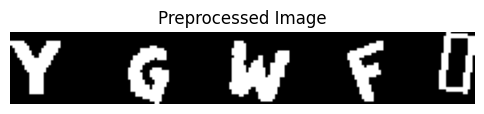

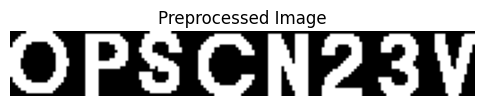

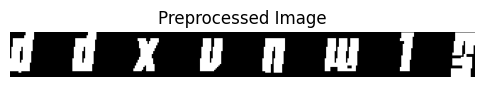

In [7]:
def preprocess_image(image_path):
    # Load image in grayscale
    image = cv.imread(image_path, cv.IMREAD_GRAYSCALE)
    
    # Noise removal and binarization
    noiseline = get_noiseline(image, first="dilation", k1size=2, k2size=2)
    clean_image = remove_noiseline(image, noiseline)
    
    # Dilation and erosion to highlight characters
    dilated_image = dilation(clean_image)
    eroded_image = erosion_line(dilated_image)
    
    # Crop the image to remove unnecessary whitespace
    coords = cv.findNonZero(255 - eroded_image)
    if coords is None:
        print("No non-white coordinates found.")
        return None
    
    x, y, w, h = cv.boundingRect(coords)
    cropped_image = eroded_image[y:y + h, x:x + w]
    
    # Convert to binary (black and white)
    thresh = np.where(cropped_image == 255, 255, 0).astype(np.uint8)
    binary_image = cv.bitwise_not(thresh)
    
    return binary_image

# Example usage
for image_path in train_images_paths[:15]:
    binary_image = preprocess_image(image_path)
    show_image("Preprocessed Image", binary_image)

In [8]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

def segment_characters(binary_image):
    """
    Segment characters from a binary image and show bounding boxes.
    """
    # Step 1: Find contours in the binary image
    contours, _ = cv.findContours(binary_image, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_SIMPLE)
    character_regions = []
    
    # Step 2: Extract bounding boxes from contours
    for contour in contours:
        (x, y, w, h) = cv.boundingRect(contour)
        character_regions.append((x, y, w, h))
    
    # Step 3: Sort bounding boxes by x-coordinate
    character_regions = sorted(character_regions, key=lambda region: region[0])

    # Convert list to numpy array for NMS
    array_character_regions = np.array(character_regions)

    # Step 4: Apply Non-Maximum Suppression (NMS)
    nms_boxes = non_max_suppression_fast(array_character_regions, overlap_thresh=0.3)

    # Step 5: Merge overlapping bounding boxes (if necessary)
    merged_boxes = merge_same_letter_bounding_boxes(nms_boxes)
    
    # Step 6: Extract character images with padding and draw bounding boxes
    character_images = []
    padded_character_images = []
    output_image = cv.cvtColor(binary_image, cv.COLOR_GRAY2BGR)  # Convert to color for visualization

    for (x, y, w, h) in merged_boxes:
        # Extract the character image
        character_img = binary_image[y:y + h, x:x + w]

        # Add 10px white padding to the character image
        padding = 15
        padded_img = cv.copyMakeBorder(character_img, padding, padding, padding, padding, cv.BORDER_CONSTANT, value=255)
        padded_character_images.append(padded_img)
        
        character_images.append(character_img)
        
        # Draw bounding box on the output image (optional)
        # cv.rectangle(output_image, (x, y), (x + w, y + h), (0, 255, 0), 2)

    #Display the image with bounding boxes (optional)
    # plt.figure(figsize=(10, 6))
    # plt.title("Character Segmentation")
    # plt.imshow(output_image, cmap='gray')
    # plt.axis('off')
    # plt.show()
    
    return padded_character_images

In [9]:
matched_images = []
matched_labels = []
unmatched_paths = []

for image_path in train_images_paths:
    # Get label from file name
    label = image_path.name.split(".png")[0]
    
    # Check if the label is alphanumeric
    if re.match("^[a-zA-Z0-9]+$", label):
        binary_image = preprocess_image(image_path)
        character_images = segment_characters(binary_image)

        ### WHEN TESTING REMOVE THIS
        # Check if segmentation matches the label length
        if len(character_images) == len(label):
            matched_images.append(character_images) # character_images is a list, so matches_images is 2d array
            matched_labels.append(label)
        else:
            # Unmatched data is ignored in this step
            unmatched_paths.append(label)
            pass

print("Matched: ", len(matched_images))
print("Unmatched: ", len(unmatched_paths))

Matched:  6784
Unmatched:  1214


In [10]:
# Enable memory growth for GPUs
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"Enabled memory growth on {len(gpus)} GPU(s)")
    except RuntimeError as e:
        print(e)
else:
    print("No GPUs detected")
# Initialize lists for character images and labels
train_images = []
train_labels = []

for character_images, label in zip(matched_images, matched_labels):
    for char_img, char_label in zip(character_images, label):
        # Resize each character image to 128x128
        resized_char_img = cv.resize(char_img, (128, 128), interpolation=cv.INTER_AREA)
        
        # Normalize to [0, 1] range
        normalized_img = resized_char_img / 255.0
        
        # Append to training data lists
        train_images.append(normalized_img)
        train_labels.append(char_label)

# Convert lists to numpy arrays
train_images = np.array(train_images).reshape(-1, 128, 128, 1)  # Add a channel dimension for grayscale
train_labels = np.array(train_labels)

print("Training data prepared:", train_images.shape, train_labels.shape)

Enabled memory growth on 2 GPU(s)
Training data prepared: (40448, 128, 128, 1) (40448,)


In [11]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.metrics import Precision, Recall
    
# Encode labels to integers
label_encoder = LabelEncoder()
encoded_labels = label_encoder.fit_transform(train_labels)

# Convert labels to one-hot encoding
encoded_labels = to_categorical(encoded_labels)

# Define the updated CNN model with input shape (128, 160, 1)
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(128, 128, 1)),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Conv2D(128, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Conv2D(256, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.5),  # Reduced dropout rate to 30%
    Dense(len(label_encoder.classes_), activation='softmax')
])

# Configure early stopping
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    mode='min',
    restore_best_weights=True
)

# Compile the model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy', Precision(), Recall()]
)

# Train the model
history = model.fit(
    train_images, encoded_labels,
    epochs=50,
    batch_size=16,
    validation_split=0.2,
    callbacks=[early_stopping]
)

/opt/conda/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50


I0000 00:00:1731754349.647592      69 service.cc:145] XLA service 0x7bf044014830 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1731754349.647647      69 service.cc:153]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1731754349.647653      69 service.cc:153]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5


  12/2023 ━━━━━━━━━━━━━━━━━━━━ 32s 16ms/step - accuracy: 0.0378 - loss: 14.3152 - precision: 0.0317 - recall: 0.0246

I0000 00:00:1731754360.938842      69 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


2023/2023 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.0548 - loss: 4.0243 - precision: 0.2428 - recall: 0.0096

I0000 00:00:1731754387.792383      67 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'input_reduce_select_fusion_3', 64 bytes spill stores, 64 bytes spill loads
ptxas warning : Registers are spilled to local memory in function 'input_reduce_fusion', 88 bytes spill stores, 88 bytes spill loads



2023/2023 ━━━━━━━━━━━━━━━━━━━━ 46s 15ms/step - accuracy: 0.0548 - loss: 4.0240 - precision: 0.2429 - recall: 0.0096 - val_accuracy: 0.3431 - val_loss: 2.4547 - val_precision: 0.8436 - val_recall: 0.1000
Epoch 2/50
2023/2023 ━━━━━━━━━━━━━━━━━━━━ 24s 12ms/step - accuracy: 0.2126 - loss: 2.7641 - precision: 0.6127 - recall: 0.0930 - val_accuracy: 0.5523 - val_loss: 1.6720 - val_precision: 0.8707 - val_recall: 0.2805
Epoch 3/50
2023/2023 ━━━━━━━━━━━━━━━━━━━━ 25s 12ms/step - accuracy: 0.3419 - loss: 2.1964 - precision: 0.6863 - recall: 0.1975 - val_accuracy: 0.6398 - val_loss: 1.2634 - val_precision: 0.8770 - val_recall: 0.4424
Epoch 4/50
2023/2023 ━━━━━━━━━━━━━━━━━━━━ 25s 12ms/step - accuracy: 0.4506 - loss: 1.7901 - precision: 0.7336 - recall: 0.3106 - val_accuracy: 0.6697 - val_loss: 1.4226 - val_precision: 0.8207 - val_recall: 0.5379
Epoch 5/50
2023/2023 ━━━━━━━━━━━━━━━━━━━━ 25s 12ms/step - accuracy: 0.5505 - loss: 1.4885 - precision: 0.7757 - recall: 0.4230 - val_accuracy: 0.6844 - val

In [12]:
# Initialize lists for character images and labels
test_images = []
test_labels = []

for image_path in test_images_paths:
    label = image_path.name.split(".png")[0]
    if re.match("^[a-zA-Z0-9]+$", label):
        binary_image = preprocess_image(image_path)
        character_images = segment_characters(binary_image)
        
        for char_img, char_label in zip(character_images, label):
            # Resize each character image to 28x28
            resized_img = cv.resize(char_img, (128, 128), interpolation=cv.INTER_AREA)
            # Normalize to [0, 1] range
            normalized_img = resized_img / 255.0
            # Append to test data lists
            test_images.append(normalized_img)
            test_labels.append(char_label)

# Convert lists to numpy arrays
test_images = np.array(test_images).reshape(-1, 128, 128, 1)  # Add a channel dimension for grayscale
test_labels = np.array(test_labels)

# Encode and one-hot encode test labels
encoded_test_labels = label_encoder.transform(test_labels)
encoded_test_labels = to_categorical(encoded_test_labels)

print("Test data prepared:", test_images.shape, encoded_test_labels.shape)

Test data prepared: (11785, 128, 128, 1) (11785, 36)


In [13]:
# Evaluate on the test set and unpack all metrics
test_loss, test_accuracy, test_precision, test_recall = model.evaluate(test_images, encoded_test_labels)

# Print out each metric
print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)
print("Test Precision:", test_precision)
print("Test Recall:", test_recall)

369/369 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.7379 - loss: 1.8320 - precision: 0.8354 - recall: 0.7085
Test Loss: 1.8475098609924316
Test Accuracy: 0.7373780012130737
Test Precision: 0.8348919153213501
Test Recall: 0.7045396566390991


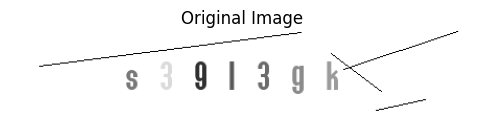

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 719ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
Predicted CAPTCHA: s3gi3gk
Actual label: /kaggle/input/captcha-dataset/test/s39l3gk.png


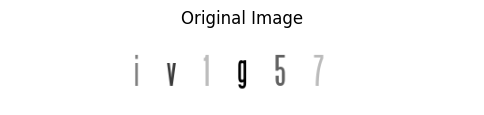

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
Predicted CAPTCHA: iv1g51
Actual label: /kaggle/input/captcha-dataset/test/iv1g57.png


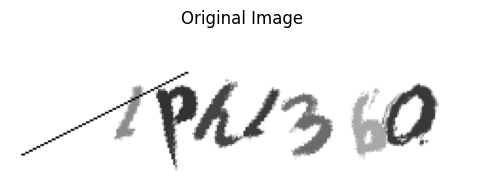

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
Predicted CAPTCHA: lpw3w
Actual label: /kaggle/input/captcha-dataset/test/lphl360.png


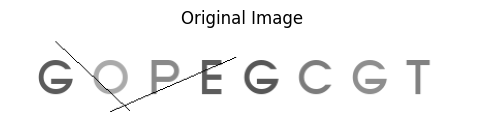

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
Predicted CAPTCHA: g0pegcgt
Actual label: /kaggle/input/captcha-dataset/test/gopegcgt.png


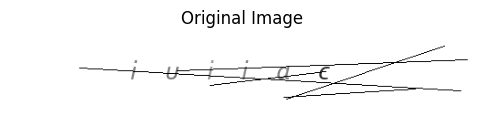

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
Predicted CAPTCHA: iuiiac
Actual label: /kaggle/input/captcha-dataset/test/iuiiac.png


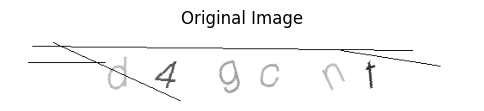

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
Predicted CAPTCHA: d4gcnt
Actual label: /kaggle/input/captcha-dataset/test/d4gcnt.png


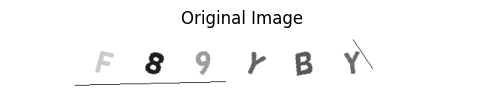

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
Predicted CAPTCHA: f89yby
Actual label: /kaggle/input/captcha-dataset/test/f89yby.png


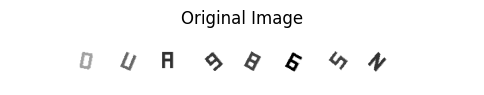

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
Predicted CAPTCHA: oua9b65n
Actual label: /kaggle/input/captcha-dataset/test/dua9865n.png


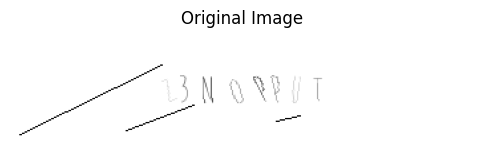

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
Predicted CA

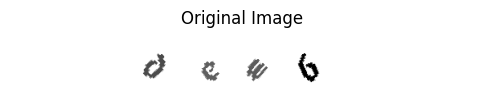

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
Predicted CAPTCHA: dgw6
Actual label: /kaggle/input/captcha-dataset/test/dew6.png


In [14]:
def recognize_captcha(image_path):
    # Step 1: Preprocess and segment the image
    binary_image = preprocess_image(image_path)
    character_images = segment_characters(binary_image)
    
    # Step 2: Predict each character
    predicted_label = ""
    for char_img in character_images:
        # Resize and normalize the character image
        resized_img = cv.resize(char_img, (128, 128)) / 255.0
        resized_img = resized_img.reshape(1, 128, 128, 1)
        
        # Predict the character
        prediction = model.predict(resized_img)
        predicted_char = label_encoder.inverse_transform([np.argmax(prediction)])[0]
        predicted_label += predicted_char
    
    return predicted_label

# Example usage
for image_path in test_images_paths[:10]:
    image = cv.imread(image_path, cv.IMREAD_GRAYSCALE)
    show_image("Original Image", image)
    predicted_captcha = recognize_captcha(image_path)
    print("Predicted CAPTCHA:", predicted_captcha)
    print("Actual label:", image_path) 